## Sección 3: Preparación del Dataset y Preprocesamiento (Pipeline)

Para asegurar la validez académica del modelo, dividimos los datos temporalmente:
* **Entrenamiento (Train):** Partidos hasta diciembre de 2025.
* **Prueba (Test):** Partidos posteriores (más de 100 encuentros reales para validar la IA).

**El Pipeline de Scikit-Learn:**
* **`StandardScaler`:** Estandariza las variables continuas (xG, Valor de Mercado) para que la Red Neuronal procese magnitudes homogéneas.
* **`OrdinalEncoder`:** Convierte las variables categóricas (Entrenadores, Equipos, Formaciones) en identificadores numéricos que alimentarán las capas de *Embedding*.

In [29]:
import pandas as pd
import numpy as np
from datetime import datetime
from google.colab import drive
drive.mount('/content/drive')
df_completo_modelo = pd.read_csv('/content/drive/MyDrive/football_data/df_completo_modelo.csv')
df_modelo_por_equipo = pd.read_csv('/content/drive/MyDrive/football_data/df_completo_por_equipos.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [30]:
# Cambiamos la fecha de corte para tener unos 100-150 partidos de prueba
fecha_corte = '2025-12-31'

df_train = df_completo_modelo[df_completo_modelo['Fecha'] <= fecha_corte].copy()
df_test = df_completo_modelo[df_completo_modelo['Fecha'] > fecha_corte].copy()

print(f"Partidos para entrenar: {len(df_train)}")
print(f"Partidos para Test/Predicción: {len(df_test)}")


Partidos para entrenar: 2067
Partidos para Test/Predicción: 116


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
import joblib # Para guardar el pipeline en disco
import pandas as pd

# 1. DEFINIR LAS CESTAS DE VARIABLES EXACTAS
# Variables categóricas (Entrenadores, Formaciones, Equipos)
cols_cat_L = ['club_id_L', 'formation_L', 'manager_name_L']
cols_cat_V = ['club_id_V', 'formation_V', 'manager_name_V']
cols_categoricas = cols_cat_L + cols_cat_V

# Variables a ignorar (Identificadores del partido)
cols_a_ignorar = ['game_id', 'Fecha', 'resultado_final', 'Equipo_L', 'Equipo_V', 'hora_L', 'hora_V', 'target']

# Variables Continuas (Todo lo demás: Understat + Transfermarkt numérico)
cols_continuas = [col for col in df_train.columns if col not in cols_categoricas + cols_a_ignorar]

# 2. CREAR LOS TRANSFORMADORES
# Para las numéricas: StandardScaler (Media 0, Varianza 1)
scaler_numerico = StandardScaler()

# Para las categóricas: OrdinalEncoder
# (Convierte texto/IDs en enteros 0, 1, 2... ideal para Embeddings de Keras).
# handle_unknown='use_encoded_value' es vital: si en el futuro aparece un entrenador nuevo,
# no dará error, le asignará el valor -1 (que Keras puede ignorar).
encoder_categorico = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# 3. ENSAMBLAR EL COLUMN TRANSFORMER
preprocesador = ColumnTransformer(
    transformers=[
        ('num', scaler_numerico, cols_continuas),
        ('cat', encoder_categorico, cols_categoricas)
    ],
    remainder='drop' # Ignoramos las columnas que no están en num ni cat (las de 'cols_a_ignorar')
)

# 4. APLICAR EL PIPELINE (Y mantener el formato DataFrame)
# Scikit-learn 1.2+ permite devolver un DataFrame en lugar de un array de Numpy
preprocesador.set_output(transform="pandas")

# Entrenamos y transformamos Train
X_train_procesado = preprocesador.fit_transform(df_train)

# Solo transformamos Test (¡Sin hacer fit para no ver el futuro!)
X_test_procesado = preprocesador.transform(df_test)

# Separamos la variable objetivo (Y)
y_train = df_train['resultado_final'].values
y_test = df_test['resultado_final'].values

# 5. GUARDAR EL PIPELINE PARA EL FUTURO
joblib.dump(preprocesador, 'pipeline_preprocesamiento_tfg.pkl')

print("Pipeline ejecutado y guardado con éxito.")
print(f"Forma de X_train_procesado: {X_train_procesado.shape}")

Pipeline ejecutado y guardado con éxito.
Forma de X_train_procesado: (2067, 88)


In [32]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Convertir texto a números enteros (0, 1, 2)
le_target = LabelEncoder()
y_train_num = le_target.fit_transform(df_train['resultado_final'])
y_test_num = le_target.transform(df_test['resultado_final'])

# 2. Aplicar One-Hot Encoding para Keras
y_train_keras = to_categorical(y_train_num, num_classes=3)
y_test_keras = to_categorical(y_test_num, num_classes=3)

print(f"Clases detectadas: {le_target.classes_}")
print(f"Ejemplo de y_train transformado (etiqueta '{df_train['resultado_final'].iloc[0]}'): {y_train_keras[0]}")

Clases detectadas: ['A' 'D' 'H']
Ejemplo de y_train transformado (etiqueta 'H'): [0. 0. 1.]


In [33]:
# Extraemos las variables numéricas (Promedios, Edades, Valores de Mercado, xG...)
cols_num = [col for col in X_train_procesado.columns if col.startswith('num__')]

X_train_num = X_train_procesado[cols_num].astype('float32')
X_test_num = X_test_procesado[cols_num].astype('float32')

# Extraemos las variables categóricas (Para las capas de Embedding)
# Entrenadores
X_train_manager_L = X_train_procesado['cat__manager_name_L'].values
X_train_manager_V = X_train_procesado['cat__manager_name_V'].values
# Formaciones
X_train_form_L = X_train_procesado['cat__formation_L'].values
X_train_form_V = X_train_procesado['cat__formation_V'].values
# Equipos (Identidad del club)
X_train_club_L = X_train_procesado['cat__club_id_L'].values
X_train_club_V = X_train_procesado['cat__club_id_V'].values

# Hacemos lo mismo para el Set de Test
X_test_manager_L = X_test_procesado['cat__manager_name_L'].values
X_test_manager_V = X_test_procesado['cat__manager_name_V'].values
X_test_form_L = X_test_procesado['cat__formation_L'].values
X_test_form_V = X_test_procesado['cat__formation_V'].values
X_test_club_L = X_test_procesado['cat__club_id_L'].values
X_test_club_V = X_test_procesado['cat__club_id_V'].values

## Sección 5: Arquitectura de la Red Neuronal (Deep Learning)
Para manejar simultáneamente variables continuas (números) y categóricas (nombres y tácticas), diseñamos una **Red Neuronal Multientrada** utilizando la API Funcional de Keras.

**Estructura del Modelo:**
1. **Capas de Embedding:** Aprenden representaciones vectoriales del contexto. Por ejemplo, convierten el identificador de un entrenador en un vector matemático que captura su "estilo de juego".
2. **Capa de Fusión (Concatenate):** Une el aprendizaje táctico/identitario con las métricas puras de rendimiento y valor de mercado.
3. **Capas Densas Ocultas:** Motor de decisión con técnicas de regularización (`Dropout`, `BatchNormalization`) para evitar el sobreajuste.
4. **Capa de Salida:** 3 neuronas con activación `Softmax` que devuelven la probabilidad matemática de Victoria Local (1), Empate (X) o Victoria Visitante (2).

In [34]:
from tensorflow.keras.layers import Input, Dense, Embedding, Concatenate, Dropout, BatchNormalization, Flatten
from tensorflow.keras.models import Model

# 1. Definir los tamaños máximos de vocabulario para los Embeddings (Max ID + un pequeño margen)
# Usamos el OrdinalEncoder previo para saber cuántos únicos hay
max_clubs = int(max(X_train_club_L.max(), X_train_club_V.max())) + 2
max_managers = int(max(X_train_manager_L.max(), X_train_manager_V.max())) + 2
max_forms = int(max(X_train_form_L.max(), X_train_form_V.max())) + 2

# 2. DEFINIR LAS ENTRADAS (INPUTS)
in_num = Input(shape=(X_train_num.shape[1],), name='entrada_numericas')

in_club_L = Input(shape=(1,), name='entrada_club_L')
in_club_V = Input(shape=(1,), name='entrada_club_V')
in_manager_L = Input(shape=(1,), name='entrada_manager_L')
in_manager_V = Input(shape=(1,), name='entrada_manager_V')
in_form_L = Input(shape=(1,), name='entrada_form_L')
in_form_V = Input(shape=(1,), name='entrada_form_V')

# 3. CREAR LAS CAPAS DE EMBEDDING (Diccionarios semánticos de la IA)
# Misma capa de embedding para Local y Visitante porque "Bordalás" significa lo mismo en ambos lados
emb_club = Embedding(input_dim=max_clubs, output_dim=8, name='emb_equipo')
emb_manager = Embedding(input_dim=max_managers, output_dim=8, name='emb_entrenador')
emb_form = Embedding(input_dim=max_forms, output_dim=4, name='emb_formacion')

# Aplicamos los embeddings y aplanamos (Flatten)
vec_club_L = Flatten()(emb_club(in_club_L))
vec_club_V = Flatten()(emb_club(in_club_V))
vec_manager_L = Flatten()(emb_manager(in_manager_L))
vec_manager_V = Flatten()(emb_manager(in_manager_V))
vec_form_L = Flatten()(emb_form(in_form_L))
vec_form_V = Flatten()(emb_form(in_form_V))

# 4. FUSIÓN (CONCATENATE) - Unimos estadísticas y contexto
merged = Concatenate()([
    in_num,
    vec_club_L, vec_club_V,
    vec_manager_L, vec_manager_V,
    vec_form_L, vec_form_V
])

# 5. CAPAS OCULTAS (El motor de decisión)
x = Dense(258, activation='relu')(merged)
x = BatchNormalization()(x)
x = Dropout(0.5)(x) # Evitamos el sobreajuste (overfitting)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# 6. SALIDA (3 Neuronas para 1, X, 2 usando Softmax)
output = Dense(3, activation='softmax', name='salida_probabilidades')(x)

# 7. COMPILACIÓN DEL MODELO
modelo_tfg = Model(
    inputs=[in_num, in_club_L, in_club_V, in_manager_L, in_manager_V, in_form_L, in_form_V],
    outputs=output
)

modelo_tfg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Imprimimos la arquitectura
modelo_tfg.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ entrada_club_L      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_club_V      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_manager_L   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_manager_V   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_form_L      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_form_V      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_equipo          │ (None, 1, 8)      │        232 │ entrada_club_L[0… │
│ (Embedding)         │                   │            │ entrada_club_V[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_entrenador      │ (None, 1, 8)      │        656 │ entrada_manager_… │
│ (Embedding)         │                   │            │ entrada_manager_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ emb_formacion       │ (None, 1, 4)      │        108 │ entrada_form_L[0… │
│ (Embedding)         │                   │            │ entrada_form_V[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ entrada_numericas   │ (None, 82)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_18          │ (None, 8)         │          0 │ emb_equipo[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_19          │ (None, 8)         │          0 │ emb_equipo[1][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_20          │ (None, 8)         │          0 │ emb_entrenador[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_21          │ (None, 8)         │          0 │ emb_entrenador[1… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_22          │ (None, 4)         │          0 │ emb_formacion[0]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_23          │ (None, 4)         │          0 │ emb_formacion[1]… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 122)       │          0 │ entrada_numerica

 Total params: 67,301 (262.89 KB)

 Trainable params: 66,785 (260.88 KB)

 Non-trainable params: 516 (2.02 KB)

## Sección 6: Entrenamiento y Evaluación del Modelo
Durante el entrenamiento, implementamos un mecanismo de **Early Stopping** (parada temprana). El algoritmo monitoriza la pérdida en el conjunto de validación (`val_loss`) y detiene el entrenamiento automáticamente si detecta que la red neuronal empieza a memorizar el pasado en lugar de generalizar reglas útiles, restaurando los pesos de su época más brillante.

Iniciando el entrenamiento de la Red Neuronal...
Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.3967 - loss: 1.7749 - val_accuracy: 0.5000 - val_loss: 1.0144
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4257 - loss: 1.4835 - val_accuracy: 0.4741 - val_loss: 1.0172
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4693 - loss: 1.2742 - val_accuracy: 0.5000 - val_loss: 1.0279
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4620 - loss: 1.2031 - val_accuracy: 0.5172 - val_loss: 1.0163
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4698 - loss: 1.1562 - val_accuracy: 0.5086 - val_loss: 1.0099
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4809 - loss: 1.0912 - val_accuracy: 0.5000 - val_loss: 1.0143
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4881 - loss: 1.0523 - val_accuracy: 0.5431 - val_loss: 1.0040
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy

Text(0.5, 1.0, 'Precisión (Accuracy) durante el Entrenamiento')

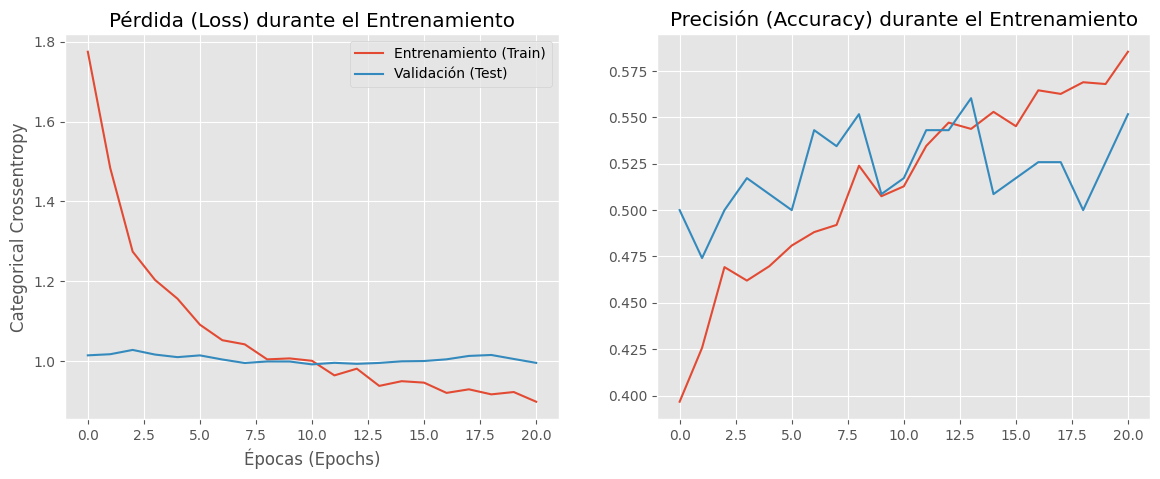

In [35]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. EMPAQUETAR LOS INPUTS
# El orden debe ser EXACTAMENTE el mismo que en la lista 'inputs=[...]' de tu modelo
entradas_train = [
    X_train_num,
    X_train_club_L, X_train_club_V,
    X_train_manager_L, X_train_manager_V,
    X_train_form_L, X_train_form_V
]

entradas_test = [
    X_test_num,
    X_test_club_L, X_test_club_V,
    X_test_manager_L, X_test_manager_V,
    X_test_form_L, X_test_form_V
]

# 2. CONFIGURAR EL EARLY STOPPING
# Si la pérdida en validación (val_loss) no mejora durante 10 epochs seguidos, paramos.
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True # Se queda con los pesos del mejor epoch, no del último
)

# 3. ENTRENAMIENTO (FIT)
print("Iniciando el entrenamiento de la Red Neuronal...")
historial = modelo_tfg.fit(
    x=entradas_train,
    y=y_train_keras,
    validation_data=(entradas_test, y_test_keras),
    epochs=100,          # Máximo de pasadas, el Early Stopping lo parará antes seguramente
    batch_size=32,       # Analiza los partidos de 32 en 32
    callbacks=[early_stop],
    verbose=1
)
print("¡Entrenamiento completado!")

# 4. GRAFICAR EL RENDIMIENTO (Crucial para tu TFG)
plt.style.use('ggplot')
plt.figure(figsize=(14, 5))

# Gráfica de Pérdida (Loss) - Mide el error (Queremos que baje)
plt.subplot(1, 2, 1)
plt.plot(historial.history['loss'], label='Entrenamiento (Train)')
plt.plot(historial.history['val_loss'], label='Validación (Test)')
plt.title('Pérdida (Loss) durante el Entrenamiento')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Categorical Crossentropy')
plt.legend()

# Gráfica de Precisión (Accuracy) - Mide el % de acierto (Queremos que suba)
plt.subplot(1, 2, 2)
plt.plot(historial.history['accuracy'], label='Entrenamiento (Train)')
plt.plot(historial.history['val_accuracy'], label='Validación (Test)')
plt.title('Precisión (Accuracy) durante el Entrenamiento')


## Sección 7: Inferencia y Simulación de Montecarlo
El objetivo final de este proyecto no es ofrecer un pronóstico seco, sino cuantificar la incertidumbre del deporte.

Para ello, encapsulamos el preprocesamiento y la inferencia de la IA en una función. Posteriormente, utilizamos un **Motor de Simulación de Montecarlo** que, basándose en las probabilidades exactas devueltas por la Red Neuronal, simula el desarrollo del encuentro miles de veces (universos paralelos) para visualizar de forma clara los escenarios estadísticos más probables.

In [36]:
# Imprimimos las columnas numéricas que el modelo está usando para predecir
print("COLUMNAS NUMÉRICAS EN LA RED NEURONAL:")
for col in cols_num:
    print(col)

COLUMNAS NUMÉRICAS EN LA RED NEURONAL:
num__xpts_avg5_L
num__ppda_avg5_L
num__corners_avg5_L
num__faltas_avg5_L
num__amarillas_avg5_L
num__rojas_avg5_L
num__diff_xg_avg5_L
num__diff_tiros_puerta_avg5_L
num__diff_tiros_avg5_L
num__diff_pases_area_avg5_L
num__diff_xpts_avg5_L
num__diff_corners_avg5_L
num__diff_faltas_avg5_L
num__diff_amarillas_avg5_L
num__diff_ratio_presion_avg5_L
num__diff_dominio_ofensivo_avg5_L
num__diff_agresividad_ofensiva_avg5_L
num__diff_disciplina_avg5_L
num__xpts_ewma5_L
num__ppda_ewma5_L
num__corners_ewma5_L
num__faltas_ewma5_L
num__amarillas_ewma5_L
num__rojas_ewma5_L
num__diff_xg_ewma5_L
num__diff_tiros_puerta_ewma5_L
num__diff_tiros_ewma5_L
num__diff_pases_area_ewma5_L
num__diff_xpts_ewma5_L
num__diff_corners_ewma5_L
num__diff_faltas_ewma5_L
num__diff_amarillas_ewma5_L
num__diff_ratio_presion_ewma5_L
num__diff_dominio_ofensivo_ewma5_L
num__diff_agresividad_ofensiva_ewma5_L
num__diff_disciplina_ewma5_L
num__xi_market_value_L
num__xi_average_age_L
num__xi_aver

In [37]:
import pandas as pd
import numpy as np

def predecir_partido(equipo_local, equipo_visitante, manager_L, manager_V, form_L, form_V):
    """
    Prepara los datos pre-partido de dos equipos y devuelve las probabilidades de la IA.
    """
    # 1. Buscar el último estado de forma de cada equipo (la última fila disponible antes de simular)
    # Reemplaza 'df_modelo_base' por el nombre de tu dataframe que usas antes de hacer Train/Test Split

    stats_L = df_modelo_por_equipo[df_modelo_por_equipo['Equipo'] == equipo_local].sort_values('Fecha').iloc[-1:].copy()
    stats_V = df_modelo_por_equipo[df_modelo_por_equipo['Equipo'] == equipo_visitante].sort_values('Fecha').iloc[-1:].copy()

    if stats_L.empty or stats_V.empty:
        return "Error: Uno de los equipos no está en la base de datos."

    # 2. Renombrar columnas con sufijos _L y _V como espera el Pipeline
    stats_L = stats_L.add_suffix('_L')
    stats_V = stats_V.add_suffix('_V')

    # 3. Juntar ambas mitades en un solo partido virtual
    partido_futuro = pd.concat([stats_L.reset_index(drop=True), stats_V.reset_index(drop=True)], axis=1)

    # 4. Sobrescribir el Contexto con la información del día (1 hora antes del partido)
    partido_futuro['manager_name_L'] = manager_L
    partido_futuro['manager_name_V'] = manager_V
    partido_futuro['formation_L'] = form_L
    partido_futuro['formation_V'] = form_V

    # Variables dummy para que el Pipeline no falle (las ignorará)
    partido_futuro['game_id'] = 999999
    partido_futuro['Fecha'] = '2026-05-01'
    partido_futuro['resultado_final'] = 'H'
    partido_futuro['Equipo_L'] = equipo_local
    partido_futuro['Equipo_V'] = equipo_visitante
    partido_futuro['hora_L'] = '21:00'
    partido_futuro['hora_V'] = '21:00'

    # 5. PASAR POR EL PIPELINE DE PREPROCESAMIENTO
    partido_procesado = preprocesador.transform(partido_futuro)

    # 6. SEPARAR LOS INPUTS PARA KERAS
    cols_num = [col for col in partido_procesado.columns if col.startswith('num__')]

    X_num = partido_procesado[cols_num].astype('float32')
    X_club_L = partido_procesado['cat__club_id_L'].values
    X_club_V = partido_procesado['cat__club_id_V'].values
    X_man_L = partido_procesado['cat__manager_name_L'].values
    X_man_V = partido_procesado['cat__manager_name_V'].values
    X_form_L = partido_procesado['cat__formation_L'].values
    X_form_V = partido_procesado['cat__formation_V'].values

    entradas_pred = [X_num, X_club_L, X_club_V, X_man_L, X_man_V, X_form_L, X_form_V]

    # 7. PREDECIR CON LA RED NEURONAL
    probabilidades = modelo_tfg.predict(entradas_pred, verbose=0)[0]

    return probabilidades

⚽ Analizando datos pre-partido para: Real Madrid vs Barcelona ⚽
--------------------------------------------------
Iniciando simulación de Montecarlo (10000 iteraciones)...


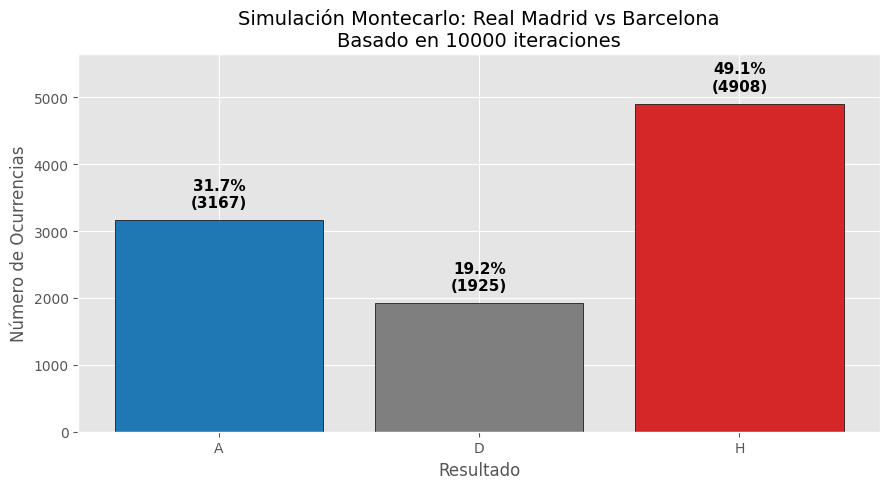

In [38]:
import matplotlib.pyplot as plt

def simulacion_montecarlo_partido(equipo_local, equipo_visitante, manager_L, manager_V, form_L, form_V, n_simulaciones=10000):
    print(f"⚽ Analizando datos pre-partido para: {equipo_local} vs {equipo_visitante} ⚽")
    print("-" * 50)

    # Extraemos probabilidades exactas
    probabilidades = predecir_partido(equipo_local, equipo_visitante, manager_L, manager_V, form_L, form_V)

    if isinstance(probabilidades, str):
        print(probabilidades)
        return

    clases = le_target.classes_

    print(f"Iniciando simulación de Montecarlo ({n_simulaciones} iteraciones)...")

    # Simulación Estocástica
    resultados_simulados = np.random.choice(clases, size=n_simulaciones, p=probabilidades)
    conteos = {clase: np.sum(resultados_simulados == clase) for clase in clases}

    # Visualización de los resultados
    plt.style.use('ggplot')
    plt.figure(figsize=(9, 5))

    # Ajustamos colores según orden habitual: A (Visitante), D (Empate), H (Local)
    colores = ['#1f77b4', '#7f7f7f', '#d62728']

    barras = plt.bar(conteos.keys(), conteos.values(), color=colores, edgecolor='black')

    plt.title(f'Simulación Montecarlo: {equipo_local} vs {equipo_visitante}\nBasado en {n_simulaciones} iteraciones', fontsize=14)
    plt.ylabel('Número de Ocurrencias', fontsize=12)
    plt.xlabel('Resultado', fontsize=12)

    for i, barra in enumerate(barras):
        altura = barra.get_height()
        porcentaje = (altura / n_simulaciones) * 100
        plt.text(barra.get_x() + barra.get_width()/2., altura + (n_simulaciones*0.015),
                 f'{porcentaje:.1f}%\n({int(altura)})',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

    plt.ylim(0, max(conteos.values()) * 1.15)
    plt.tight_layout()
    plt.show()

    return conteos

# ==========================================
# 🧪 ZONA DE PRUEBAS: SIMULANDO EL CLÁSICO
# ==========================================
# Ajusta estos nombres exactamente a como los tienes en tu dataset
resultados = simulacion_montecarlo_partido(
    equipo_local='Real Madrid',
    equipo_visitante='Barcelona',
    manager_L='álvaro arbeloa',
    manager_V='hansi flick',
    form_L='4-3-3',
    form_V='4-3-3',
    n_simulaciones=10000
)

In [39]:
import joblib

print("Guardando los artefactos del modelo para Producción...")

# 1. Guardar la Red Neuronal (El "Cerebro")
# Usamos el formato moderno de Keras (.keras)
modelo_tfg.save('modelo_tfg.keras')
print("✅ Red Neuronal guardada como 'modelo_tfg.keras'")

# 2. Guardar el Pipeline de Preprocesamiento (StandardScaler, OrdinalEncoder, etc.)
joblib.dump(preprocesador, 'pipeline_preprocesamiento.pkl')
print("✅ Pipeline guardado como 'pipeline_preprocesamiento.pkl'")

# 3. Guardar el LabelEncoder de los resultados (H, D, A -> 0, 1, 2)
joblib.dump(le_target, 'label_encoder_target.pkl')
print("✅ Encoder de resultados guardado como 'label_encoder_target.pkl'")

Guardando los artefactos del modelo para Producción...
✅ Red Neuronal guardada como 'modelo_tfg.keras'
✅ Pipeline guardado como 'pipeline_preprocesamiento.pkl'
✅ Encoder de resultados guardado como 'label_encoder_target.pkl'


In [42]:
print("Generando archivos Big Data para S3 y Apache Hive...")

# 1. El Historial Completo (Para que Hive pueda recalcular promedios en el futuro)
# Guardamos el dataset completo antes de ser transformado por el pipeline
df_modelo_por_equipo.to_csv('datalake_historico_completo.csv', index=False)
print(f"✅ Historial completo guardado (Filas: {len(df_modelo_por_equipo)})")

# 2. Los Partidos de Test (Para mostrar métricas de rendimiento en la web)
# Si en tu web quieres tener una pestaña de "Rendimiento de la IA", la web puede
# leer este pequeño CSV para mostrar los 116 partidos donde la IA acertó/falló.
if 'df_test' in locals():
    df_test.to_csv('datalake_partidos_test.csv', index=False)
    print(f"✅ Partidos de test guardados (Filas: {len(df_test)})")
else:
    print("⚠️ df_test no encontrado en memoria. Ejecuta la celda del Train/Test split si lo necesitas.")

# 1. ESTADO DE FORMA ACTUAL (Para la inferencia en la web)
# Cogemos solo la última aparición cronológica de cada equipo
df_estado_actual = df_modelo_por_equipo.sort_values('Fecha').groupby('Equipo').tail(1)
df_estado_actual.to_csv('estado_forma_actual.csv', index=False)
print(f"✅ Estado actual guardado (Filas: {len(df_estado_actual)})")

# 2. PARTIDOS DEMO PARA LA WEB (El Test Set limpio)
# Seleccionamos las columnas que el usuario vería antes del partido
cols_demo = ['Fecha', 'Equipo_L', 'Equipo_V', 'manager_name_L', 'manager_name_V', 'formation_L', 'formation_V']
df_demo_web = df_test[cols_demo].copy()
df_demo_web.to_csv('partidos_demo_web.csv', index=False)
print(f"✅ Partidos de demostración guardados (Filas: {len(df_demo_web)})")
print("\n Archivos de Data Lake para subir a AWS S3!")

,Equipo,Fecha,hora,es_local,resultado_final,xpts_avg5,ppda_avg5,corners_avg5,faltas_avg5,amarillas_avg5,...,diff_disciplina_ewma5,club_id,game_id,xi_market_value,xi_average_age,xi_average_height,xi_total_caps,formation,manager_name,ocupacion_estadio
3713,SD Huesca,2021-05-22,16:00:00,1,D,1.17428,8.028309,3.2,14.2,1.8,...,-0.989470,5358,3451477,29400000.0,27.218468,180.363636,61.0,3-5-2,pacheta,0.000000
1282,Eibar,2021-05-22,16:00:00,1,A,1.93766,8.707079,5.8,10.0,2.0,...,-0.718836,1533,3451474,35750000.0,29.450314,180.454545,51.0,4-4-2 DOUBLE 6,josé luis mendilibar,0.000000
2041,Granada,2022-05-22,18:00:00,1,D,1.30460,9.183425,4.4,14.6,2.6,...,-0.239624,16795,3611511,49100000.0,28.930869,182.545455,15.0,4-2-3-1,aitor karanka,0.928372
218,Almeria,2023-06-04,18:00:00,0,D,1.47694,15.956427,3.2,9.0,0.8,...,0.907848,3302,3844556,46700000.0,26.349076,181.636364,50.0,4-3-3 ATTACKING,rubi,0.775353
987,Cadiz,2023-06-04,18:00:00,0,D,1.28044,12.037236,4.4,13.0,4.0,...,-1.025138,2687,3844555,33300000.0,29.924460,179.545455,100.0,4-4-2,sergio,0.786243
3675,Real Valladolid,2025-05-24,16:30:00,0,H,1.01354,20.263658,5.8,9.6,0.8,...,0.582999,366,4407568,20850000.0,26.251011,181.545455,107.0,4-4-2,álvaro rubio,0.417228
2155,Leganes,2025-05-24,16:30:00,1,H,1.07744,10.980762,3.4,13.0,2.8,...,-0.391732,1244,4407568,21200000.0,27.559953,181.909091,161.0,4-2-3-1,borja jiménez,0.798988
2079,Las Palmas,2025-05-24,16:30:00,0,H,0.89070,9.789525,6.2,11.8,2.8,...,-0.053726,472,4407569,42000000.0,25.755460,181.300000,68.0,4-2-3-1,diego martínez,1.000000
436,Athletic Club,2026-03-14,13:00:00,0,H,1.92960,9.313609,3.4,16.6,2.6,...,-0.746779,621,4645928,162700000.0,29.101612,181.727273,158.0,4-2-3-1,ernesto valverde,0.165344
4147,Valencia,2026-03-14,17:30:00,0,H,1.41558,11.484489,5.2,11.8,2.2,...,2.900027,1049,4645927,66500000.0,28.405700,181.636364,219.0,4-2-3-1,carlos corberán,0.461784


In [41]:
import pandas as pd
from IPython.display import display

archivos_exportados = [
    'datalake_historico_completo.csv',
    'datalake_partidos_test.csv',
    'estado_forma_actual.csv',
    'partidos_demo_web.csv'
]

for archivo in archivos_exportados:
    print("=" * 70)
    print(f"📄 AUDITORÍA DE ARCHIVO: {archivo}")
    print("=" * 70)

    try:
        # Leemos el archivo recién guardado
        df_revision = pd.read_csv(archivo)

        # 1. Dimensiones
        filas, columnas = df_revision.shape
        print(f"✅ TAMAÑO: {filas} filas y {columnas} columnas.\n")

        # 2. Vistazo a las columnas (Para ver si están las fechas, EWMAs, etc.)
        print("🔍 PRIMERAS 5 COLUMNAS:")
        print(list(df_revision.columns[:5]))

        print("\n🔍 ÚLTIMAS 5 COLUMNAS:")
        print(list(df_revision.columns[-5:]))

        # 3. Muestra de datos reales
        print("\n📊 MUESTRA DE LAS 2 PRIMERAS FILAS:")
        display(df_revision.head(2))
        print("\n\n")

    except FileNotFoundError:
        print(f"❌ ALERTA: No se encontró el archivo '{archivo}'. Asegúrate de haber ejecutado la celda de guardado antes.\n")

📄 AUDITORÍA DE ARCHIVO: datalake_historico_completo.csv
✅ TAMAÑO: 4367 filas y 50 columnas.

🔍 PRIMERAS 5 COLUMNAS:
['Equipo', 'Fecha', 'hora', 'es_local', 'resultado_final']

🔍 ÚLTIMAS 5 COLUMNAS:
['xi_average_height', 'xi_total_caps', 'formation', 'manager_name', 'ocupacion_estadio']

📊 MUESTRA DE LAS 2 PRIMERAS FILAS:


,Equipo,Fecha,hora,es_local,resultado_final,xpts_avg5,ppda_avg5,corners_avg5,faltas_avg5,amarillas_avg5,...,diff_disciplina_ewma5,club_id,game_id,xi_market_value,xi_average_age,xi_average_height,xi_total_caps,formation,manager_name,ocupacion_estadio
0,Alaves,2019-08-18,16:00:00,1,H,1.34312,10.843958,4.6,13.0,2.4,...,-0.001669,1108,3208623,61000000.0,27.715264,182.454545,79.0,4-1-4-1,asier garitano,0.606300
1,Alaves,2019-08-25,16:00:00,1,D,1.15990,13.150000,2.0,18.0,2.0,...,-1.000000,1108,3208639,46800000.0,27.630888,180.363636,21.0,4-1-4-1,asier garitano,0.734224





📄 AUDITORÍA DE ARCHIVO: datalake_partidos_test.csv
✅ TAMAÑO: 116 filas y 95 columnas.

🔍 PRIMERAS 5 COLUMNAS:
['game_id', 'Fecha', 'resultado_final', 'Equipo_L', 'hora_L']

🔍 ÚLTIMAS 5 COLUMNAS:
['xi_average_height_V', 'xi_total_caps_V', 'formation_V', 'manager_name_V', 'ocupacion_estadio_V']

📊 MUESTRA DE LAS 2 PRIMERAS FILAS:


,game_id,Fecha,resultado_final,Equipo_L,hora_L,xpts_avg5_L,ppda_avg5_L,corners_avg5_L,faltas_avg5_L,amarillas_avg5_L,...,diff_agresividad_ofensiva_ewma5_V,diff_disciplina_ewma5_V,club_id_V,xi_market_value_V,xi_average_age_V,xi_average_height_V,xi_total_caps_V,formation_V,manager_name_V,ocupacion_estadio_V
0,4645857,2026-01-04,D,Alaves,17:30:00,0.92794,12.204205,3.6,16.2,2.4,...,-2.052836,-1.854019,2497,24000000.0,28.392010,180.818182,134.0,4-2-3-1,guillermo almada,0.568689
1,4645795,2026-01-25,H,Alaves,20:00:00,0.70030,12.979545,4.6,10.6,2.2,...,0.885717,0.971471,150,122900000.0,27.593305,180.909091,158.0,4-2-3-1,manuel pellegrini,0.211571





📄 AUDITORÍA DE ARCHIVO: estado_forma_actual.csv
✅ TAMAÑO: 28 filas y 50 columnas.

🔍 PRIMERAS 5 COLUMNAS:
['Equipo', 'Fecha', 'hora', 'es_local', 'resultado_final']

🔍 ÚLTIMAS 5 COLUMNAS:
['xi_average_height', 'xi_total_caps', 'formation', 'manager_name', 'ocupacion_estadio']

📊 MUESTRA DE LAS 2 PRIMERAS FILAS:


,Equipo,Fecha,hora,es_local,resultado_final,xpts_avg5,ppda_avg5,corners_avg5,faltas_avg5,amarillas_avg5,...,diff_disciplina_ewma5,club_id,game_id,xi_market_value,xi_average_age,xi_average_height,xi_total_caps,formation,manager_name,ocupacion_estadio
0,SD Huesca,2021-05-22,16:00:00,1,D,1.17428,8.028309,3.2,14.2,1.8,...,-0.989470,5358,3451477,29400000.0,27.218468,180.363636,61.0,3-5-2,pacheta,0.0
1,Eibar,2021-05-22,16:00:00,1,A,1.93766,8.707079,5.8,10.0,2.0,...,-0.718836,1533,3451474,35750000.0,29.450314,180.454545,51.0,4-4-2 DOUBLE 6,josé luis mendilibar,0.0





📄 AUDITORÍA DE ARCHIVO: partidos_demo_web.csv
✅ TAMAÑO: 116 filas y 7 columnas.

🔍 PRIMERAS 5 COLUMNAS:
['Fecha', 'Equipo_L', 'Equipo_V', 'manager_name_L', 'manager_name_V']

🔍 ÚLTIMAS 5 COLUMNAS:
['Equipo_V', 'manager_name_L', 'manager_name_V', 'formation_L', 'formation_V']

📊 MUESTRA DE LAS 2 PRIMERAS FILAS:


,Fecha,Equipo_L,Equipo_V,manager_name_L,manager_name_V,formation_L,formation_V
0,2026-01-04,Alaves,Real Oviedo,eduardo coudet,guillermo almada,4-1-4-1,4-2-3-1
1,2026-01-25,Alaves,Real Betis,eduardo coudet,manuel pellegrini,4-4-2,4-2-3-1
